# EI Tuning — Results Inspector
Flexible notebook to explore output `.npy` files from the cluster.
Run cells top to bottom, edit paths as needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── EDIT THESE ────────────────────────────────────────────
RESULTS_DIR = Path("/mnt/lustre/work/buerger/bht900/TVB-schz/results")   # change to your actual path
TASK        = "normal"           # normal | shuffle_region | shuffle_subj
WEIGHT_TYPE = "gFA"              # ADC | gFA | density | number
PARC        = 129                 # 83 | 129 | 234 | 463 | 1015
SUBJECT     = "ctrl0"            # e.g. ctrl0, schz14
# ──────────────────────────────────────────────────────────

result_path = RESULTS_DIR / TASK / WEIGHT_TYPE / f"parc{PARC}" / f"{SUBJECT}.npy"
print(f"Loading: {result_path}")
print(f"Exists:  {result_path.exists()}")

Loading: /mnt/lustre/work/buerger/bht900/TVB-schz/results/normal/gFA/parc129/ctrl0.npy
Exists:  True


## 0. Check shuffle files

In [3]:
import numpy as np, os, yaml
cfg  = yaml.safe_load(open("configs/ei_tuning_config.yaml"))
data = np.load(os.path.expandvars(cfg["data_dir"]) + "/" + list(cfg["weight_types"].values())[0], allow_pickle=True).item()
keys = sorted(data.keys())
print("First 5 keys in data:", keys[:5])

shuf = np.load(os.path.expandvars(cfg["shuffle_dir"]) + "/sub_order/keys_shuffled.npy", allow_pickle=True).tolist()
print("First 5 shuffled:    ", shuf[:5])
print("Total original:", len(keys))
print("Total shuffled:", len(shuf))

First 5 keys in data: ['ctrl0', 'ctrl1', 'ctrl10', 'ctrl11', 'ctrl12']
First 5 shuffled:     ['schz0', 'ctrl15', 'schz18', 'schz20', 'schz9']
Total original: 54
Total shuffled: 54


## 1. What's inside this file?

In [2]:
data = np.load(result_path, allow_pickle=True).item()

print(f"Subject:      {data.get('subject')}")
print(f"Task:         {data.get('task')}")
print(f"Weight type:  {data.get('weight_type')}")
print(f"Parcellation: {data.get('parcellation')}")
if 'fc_subject' in data:
    print(f"FC subject:   {data['fc_subject']}")

print("\n── Keys and shapes ──────────────────────────")
for k, v in data.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:<20} shape={v.shape}  dtype={v.dtype}")
    else:
        print(f"  {k:<20} value={v}")

Subject:      ctrl0
Task:         normal
Weight type:  gFA
Parcellation: 129

── Keys and shapes ──────────────────────────
  iterations           value=2000
  bold_signal          shape=(150, 129)  dtype=float64
  raw_timeseries       shape=(180, 129)  dtype=float64
  J_i                  shape=(129,)  dtype=float64
  fc_pred              shape=(129, 129)  dtype=float64
  fc_corr              value=0.5743547203071352
  fc_rmse              value=0.1892037176456403
  wLRE                 shape=(129, 129)  dtype=float64
  wFFI                 shape=(129, 129)  dtype=float64
  fc_corr_history      shape=(2000,)  dtype=float64
  fc_rmse_history      shape=(2000,)  dtype=float64
  task                 value=normal
  subject              value=ctrl0
  weight_type          value=gFA
  parcellation         value=129


## 2. FC convergence — did the fitting work?

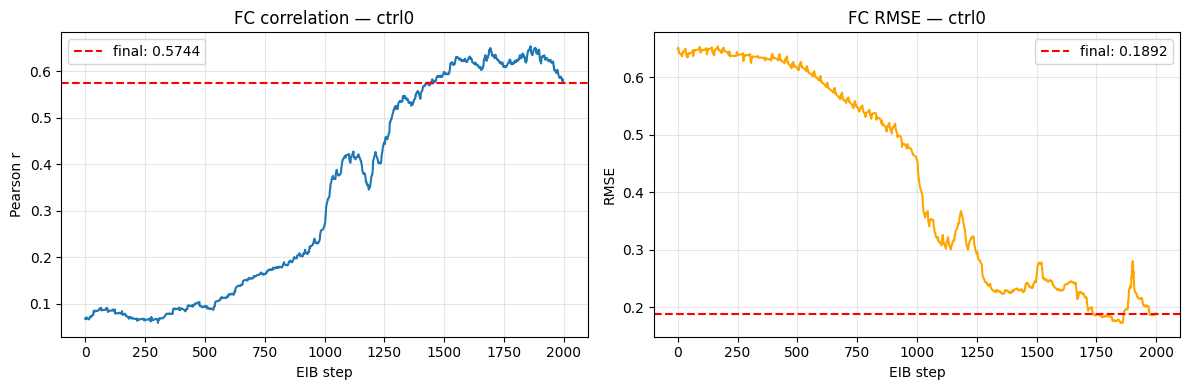

Final FC corr: 0.5744 | Final RMSE: 0.1892


In [3]:
fc_corr = data["fc_corr_history"]
fc_rmse = data["fc_rmse_history"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(fc_corr)
ax1.set_title(f"FC correlation — {SUBJECT}")
ax1.set_xlabel("EIB step")
ax1.set_ylabel("Pearson r")
ax1.axhline(fc_corr[-1], color='red', linestyle='--', label=f"final: {fc_corr[-1]:.4f}")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(fc_rmse, color='orange')
ax2.set_title(f"FC RMSE — {SUBJECT}")
ax2.set_xlabel("EIB step")
ax2.set_ylabel("RMSE")
ax2.axhline(fc_rmse[-1], color='red', linestyle='--', label=f"final: {fc_rmse[-1]:.4f}")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final FC corr: {fc_corr[-1]:.4f} | Final RMSE: {fc_rmse[-1]:.4f}")

## 3. Fitted parameters — J_i, wLRE, wFFI

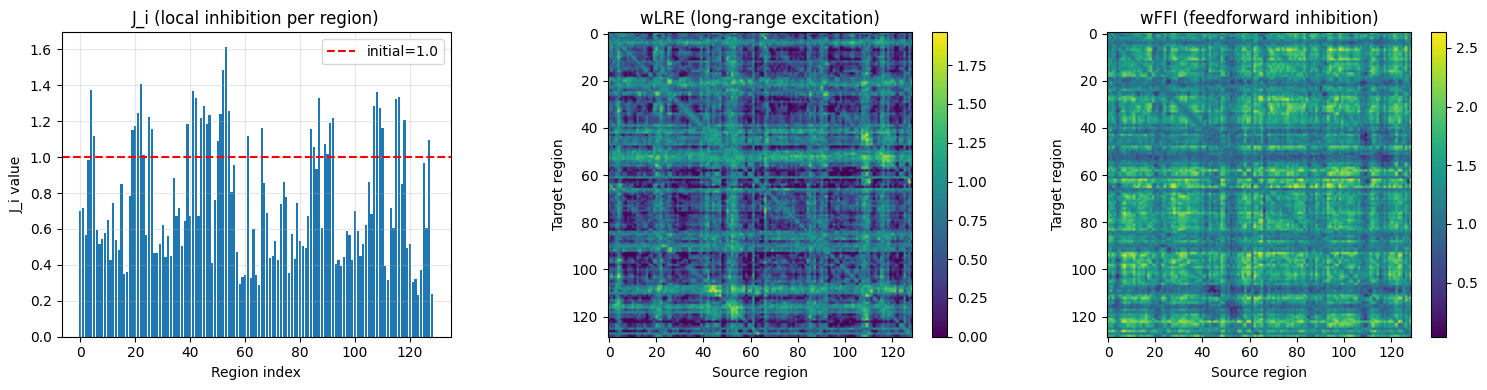

J_i  — min: 0.231  max: 1.614  mean: 0.760
wLRE — min: 0.000  max: 1.962  mean: 0.645
wFFI — min: 0.038  max: 2.632  mean: 1.361


In [4]:
J_i  = data["J_i"]    # shape [n_nodes]
wLRE = data["wLRE"]   # shape [n_nodes, n_nodes]
wFFI = data["wFFI"]   # shape [n_nodes, n_nodes]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# J_i per region
axes[0].bar(range(len(J_i)), J_i)
axes[0].set_title("J_i (local inhibition per region)")
axes[0].set_xlabel("Region index")
axes[0].set_ylabel("J_i value")
axes[0].axhline(1.0, color='red', linestyle='--', label='initial=1.0')
axes[0].legend()
axes[0].grid(alpha=0.3)

# wLRE matrix
im1 = axes[1].imshow(wLRE, cmap='viridis')
axes[1].set_title("wLRE (long-range excitation)")
axes[1].set_xlabel("Source region")
axes[1].set_ylabel("Target region")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# wFFI matrix
im2 = axes[2].imshow(wFFI, cmap='viridis')
axes[2].set_title("wFFI (feedforward inhibition)")
axes[2].set_xlabel("Source region")
axes[2].set_ylabel("Target region")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"J_i  — min: {J_i.min():.3f}  max: {J_i.max():.3f}  mean: {J_i.mean():.3f}")
print(f"wLRE — min: {wLRE.min():.3f}  max: {wLRE.max():.3f}  mean: {wLRE.mean():.3f}")
print(f"wFFI — min: {wFFI.min():.3f}  max: {wFFI.max():.3f}  mean: {wFFI.mean():.3f}")

## 4. Simulated FC vs target FC

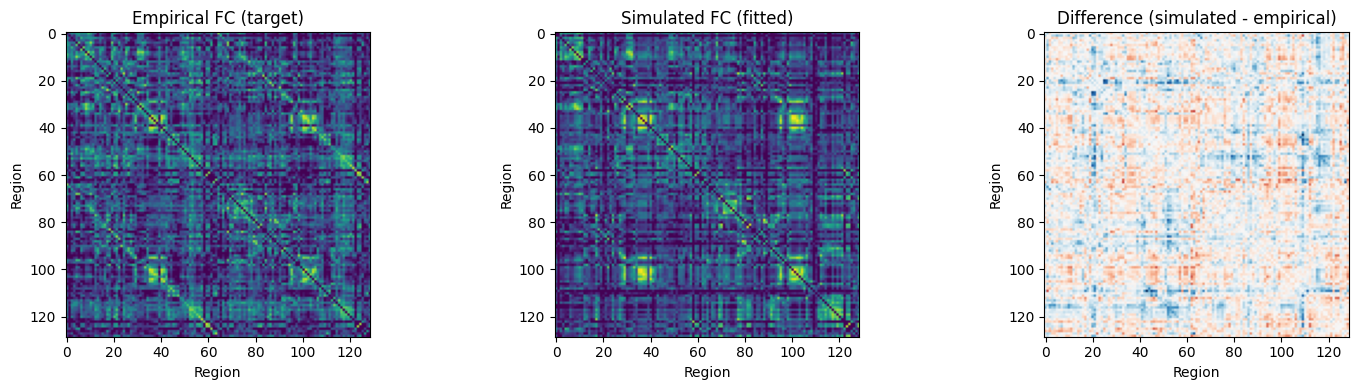

In [5]:
fc_pred = data["fc_pred"]   # simulated FC at last snapshot

# Load empirical FC target for comparison
import os
WORK      = os.environ.get("WORK", "/path/to/WORK")   # adjust if running locally
fc_all    = np.load(f"{WORK}/TVB-schz/data/FC_allsubj_allparcellations_Hagmann.npy",
                    allow_pickle=True).item()
fc_target = np.array(fc_all[SUBJECT][PARC])
fc_target = fc_target - np.diag(np.diag(fc_target))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vmin, vmax = 0, 1
axes[0].imshow(fc_target, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title("Empirical FC (target)")

axes[1].imshow(fc_pred, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title("Simulated FC (fitted)")

diff = fc_pred - fc_target
lim  = np.abs(diff).max()
axes[2].imshow(diff, cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[2].set_title("Difference (simulated - empirical)")

for ax in axes:
    ax.set_xlabel("Region")
    ax.set_ylabel("Region")

plt.tight_layout()
plt.show()

## 5. Scan all completed results — how many subjects are done?

In [6]:
tasks   = ["normal", "shuffle_region", "shuffle_subj"]
weights = ["ADC", "gFA", "density", "number"]
parcs   = [83, 129]

print(f"{'Task':<16} {'Weight':<10} {'Parc':<8} {'Done':>6}")
print("-" * 44)

for task in tasks:
    for wtype in weights:
        for parc in parcs:
            d = RESULTS_DIR / task / wtype / f"parc{parc}"
            n = len(list(d.glob("*.npy"))) if d.exists() else 0
            print(f"{task:<16} {wtype:<10} {parc:<8} {n:>6}")

Task             Weight     Parc       Done
--------------------------------------------
normal           ADC        83           54
normal           ADC        129          54
normal           gFA        83           54
normal           gFA        129          54
normal           density    83           54
normal           density    129          54
normal           number     83           54
normal           number     129          54
shuffle_region   ADC        83           54
shuffle_region   ADC        129          54
shuffle_region   gFA        83           54
shuffle_region   gFA        129          54
shuffle_region   density    83           54
shuffle_region   density    129          54
shuffle_region   number     83           54
shuffle_region   number     129          54
shuffle_subj     ADC        83           54
shuffle_subj     ADC        129          54
shuffle_subj     gFA        83           54
shuffle_subj     gFA        129          54
shuffle_subj     density    83 

## 6. Compare ctrl vs schz — final FC correlation

ctrl: n=27  mean=0.7136  std=0.0611
schz: n=27  mean=0.6904  std=0.0473


/tmp/ipykernel_750418/4009169735.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl_corrs, schz_corrs], labels=["ctrl", "schz"])


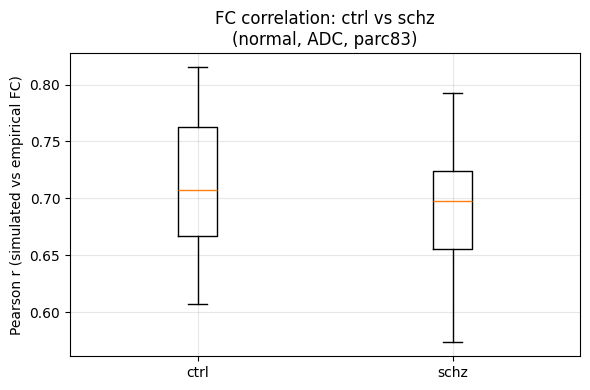

In [7]:
# ── EDIT THESE ────────────────────────────────────────────
COMPARE_TASK   = "normal"
COMPARE_WEIGHT = "ADC"
COMPARE_PARC   = 83
# ──────────────────────────────────────────────────────────

result_dir = RESULTS_DIR / COMPARE_TASK / COMPARE_WEIGHT / f"parc{COMPARE_PARC}"
files      = sorted(result_dir.glob("*.npy")) if result_dir.exists() else []

ctrl_corrs, schz_corrs = [], []

for f in files:
    d    = np.load(f, allow_pickle=True).item()
    subj = f.stem
    corr = float(d["fc_corr_history"][-1])
    if subj.startswith("ctrl"):
        ctrl_corrs.append(corr)
    elif subj.startswith("schz"):
        schz_corrs.append(corr)

print(f"ctrl: n={len(ctrl_corrs)}  mean={np.mean(ctrl_corrs):.4f}  std={np.std(ctrl_corrs):.4f}")
print(f"schz: n={len(schz_corrs)}  mean={np.mean(schz_corrs):.4f}  std={np.std(schz_corrs):.4f}")

if ctrl_corrs or schz_corrs:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot([ctrl_corrs, schz_corrs], labels=["ctrl", "schz"])
    ax.set_title(f"FC correlation: ctrl vs schz\n({COMPARE_TASK}, {COMPARE_WEIGHT}, parc{COMPARE_PARC})")
    ax.set_ylabel("Pearson r (simulated vs empirical FC)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Scratch cell — add your own checks here

In [ ]:
# Free cell — explore anything
# e.g. print raw bold signal:
# print(data["bold_signal"].shape)
# plt.plot(data["bold_signal"])

# e.g. check iterations list:
# print(data["iterations"])